In [52]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

In [53]:
df = pd.read_json("../data/supervise_ready_df.json", lines=True)

df.head(3)

,id,text,type,source,imdb_title,imdb_year,imdb_genres,imdb_plot,book_title,book_authors,...,max_trope_similarity,combined_text,sentence_matched_tropes,sentence_myth_trope_hits,has_sentence_myth_trope_hit,has_lexical_match,has_semantic_match,tropes_lexical_match,tropes_semantic_match,myth_influence_mode
0,media_acesciencefictionspecials,Ace Science Fiction Specials is a Science fict...,modern_media,Science Fiction Book Series,Science Fiction special,1986.0,"[comedy, crime, fantasy, horror, sci-fi, thril...",None,Ace Science Fiction Special,None,...,0.0,Ace Science Fiction Special Science Fiction sp...,"[EldritchAbomination, Reincarnation, DarkestHo...","[Reincarnation, DarkestHour, TheChosenOne]",True,False,True,[],"[Reincarnation, DarkestHour, TheChosenOne]",semantic_only
1,media_listofacesfdoubletitles,List of Ace SF double titles is a Science fict...,modern_media,Science Fiction Book Series,None,NaN,None,None,None,None,...,0.0,,"[AnimalMotifs, BeastMan, KarmicTrickster, TheT...","[AnimalMotifs, BeastMan, TheTrickster, Reincar...",True,False,True,[],"[AnimalMotifs, BeastMan, TheTrickster, Reincar...",semantic_only
2,media_listofacesfletter-seriessingletitles,List of Ace SF letter-series single titles is ...,modern_media,Science Fiction Book Series,None,NaN,None,None,None,None,...,0.0,,"[AnimalMotifs, BeastMan, KarmicTrickster, TheT...","[AnimalMotifs, BeastMan, TheTrickster, Reincar...",True,False,True,[],"[AnimalMotifs, BeastMan, TheTrickster, Reincar...",semantic_only


In [54]:
#first pass at myth influence: logistic regression
#prep for logistic regression
df['myth_influenced'] = df['myth_influence_mode'] != 'none'

df['myth_influenced'].value_counts(normalize=True)

positive = df[df['myth_influenced'] == True]
negative = df[df['myth_influenced'] == False]


negative_sample = negative.copy()  # take all of them

# Positive: 5× the negatives for some balance
positive_sample = positive.sample(n=30, random_state=42)

# Combine
df_balanced = pd.concat([positive_sample, negative_sample]).sample(frac=1, random_state=42).reset_index(drop=True)

# Check class distribution
df_balanced['myth_influenced'].value_counts(normalize=True)

myth_influenced
True     0.833333
False    0.166667
Name: proportion, dtype: float64

In [55]:
#feature engineering
# Select features
features = [
    "has_lexical_match",
    "has_semantic_match",
    "has_sentence_myth_trope_hit",
    "myth_hit_count",
    "max_trope_similarity",
    "inferred_media_type",
    "imdb_year"
]

X = df_balanced[features]
y = df_balanced["myth_influenced"]
X.isna().sum()

has_lexical_match               0
has_semantic_match              0
has_sentence_myth_trope_hit     0
myth_hit_count                  0
max_trope_similarity            0
inferred_media_type             0
imdb_year                      20
dtype: int64

In [56]:
# Define column types
categorical = ["inferred_media_type"]
numerical = ["myth_hit_count", "max_trope_similarity", "imdb_year"]
boolean = ["has_lexical_match", "has_semantic_match", "has_sentence_myth_trope_hit"]

# Pipelines
numeric_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler())
])

categorical_pipe = Pipeline([
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

# Combine
preprocessor = ColumnTransformer([
    ("num", numeric_pipe, numerical),
    ("cat", categorical_pipe, categorical),
    ("bool", "passthrough", boolean)
])

In [57]:


model = Pipeline([
    ("preprocess", preprocessor),
    ("clf", LogisticRegression(max_iter=1000))
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

model.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['myth_hit_count',
                                                   'max_trope_similarity',
                                                   'imdb_year']),
                                                 ('cat',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['inferred_media_type']),
                                                 ('bool', 'passthrough',
                                                  ['has_lexical_match',
                                                   'has_semantic_match',
                                                   'has_sentence_myth_trope_hit'])])),
                ('clf', LogisticRegression(max_iter=1000))])

In [58]:
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       False       1.00      1.00      1.00         1
        True       1.00      1.00      1.00         7

    accuracy                           1.00         8
   macro avg       1.00      1.00      1.00         8
weighted avg       1.00      1.00      1.00         8



In [59]:
pd.DataFrame(confusion_matrix(y_test, y_pred),
             index=["Actual: False", "Actual: True"],
             columns=["Predicted: False", "Predicted: True"])

,Predicted: False,Predicted: True
Actual: False,1,0
Actual: True,0,7


In [60]:
clf = model.named_steps['clf']
preprocessed_feature_names = (
    model.named_steps['preprocess']
    .get_feature_names_out()
)

# Map coefficients to features
coef_df = pd.DataFrame({
    "feature": preprocessed_feature_names,
    "coefficient": clf.coef_[0]
}).sort_values(by="coefficient", key=abs, ascending=False)

coef_df.head(10)

,feature,coefficient
8,bool__has_semantic_match,1.441127
9,bool__has_sentence_myth_trope_hit,1.441127
2,num__imdb_year,-0.493682
1,num__max_trope_similarity,-0.460400
3,cat__inferred_media_type_book,-0.367866
6,cat__inferred_media_type_unknown,0.331565
4,cat__inferred_media_type_both,0.148265
5,cat__inferred_media_type_screen,-0.111897
0,num__myth_hit_count,0.000000
7,bool__has_lexical_match,0.000000


In [61]:
#logistic regression isn't really the right tool for this, but it gives us a starting point
# and a sense of the feature importance. moving on to multi-class classification

df['myth_influence_mode'].value_counts()

from collections import Counter

combo_counts = Counter(
    df["has_lexical_match"].astype(str) + df["has_semantic_match"].astype(str)
)

for combo, count in combo_counts.items():
    print(f"{combo}: {count}")

FalseTrue: 2243
TrueTrue: 26
FalseFalse: 6


In [74]:
df = df[df['myth_influence_mode'] != "lexical_only"]

df_multi = pd.concat([
    df[df['myth_influence_mode'] == 'semantic_only'].sample(n=30, random_state=42),
    df[df['myth_influence_mode'] == 'both'].sample(n=6, random_state=42),
    df[df['myth_influence_mode'] == 'none'].sample(n=6, random_state=42)
])

df_multi['myth_influence_mode'].value_counts()

myth_influence_mode
semantic_only    30
both              6
none              6
Name: count, dtype: int64

In [ ]:
# Find rows with lexical match but no semantic
#just testing what the data looks like
lexical_only_test = df[
    (df['has_lexical_match'] == True) & 
    (df['has_semantic_match'] == False)
]

print(lexical_only_test.shape)

(0, 36)


In [76]:
features = [
    "has_lexical_match",
    "has_semantic_match",
    "has_sentence_myth_trope_hit",
    "myth_hit_count",
    "max_trope_similarity",
    "inferred_media_type",
    "imdb_year"
]

X = df_multi[features]
y = df_multi["myth_influence_mode"]

In [77]:
#multi-class classification

model = Pipeline([
    ("preprocess", preprocessor),
    ("clf", LogisticRegression(
        multi_class="multinomial",
        solver="lbfgs",
        max_iter=1000
    ))
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

model.fit(X_train, y_train)

/opt/anaconda3/envs/mythology/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['myth_hit_count',
                                                   'max_trope_similarity',
                                                   'imdb_year']),
                                                 ('cat',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['inferred_media_type']),
                                                 ('bool', 'passthrough',
                                                  ['has_lexical_match',
                                                   'has_semantic_match',
                                                   'has_sentence_myth_trope_hit'])])),
                ('clf',
                 LogisticRegression(max_iter=1000, multi_class='multinomial'))])

In [78]:
y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))
pd.DataFrame(confusion_matrix(y_test, y_pred),
             index=[f"Actual: {c}" for c in model.classes_],
             columns=[f"Predicted: {c}" for c in model.classes_])


               precision    recall  f1-score   support

         both       1.00      1.00      1.00         1
         none       1.00      1.00      1.00         1
semantic_only       1.00      1.00      1.00         7

     accuracy                           1.00         9
    macro avg       1.00      1.00      1.00         9
 weighted avg       1.00      1.00      1.00         9



,Predicted: both,Predicted: none,Predicted: semantic_only
Actual: both,1,0,0
Actual: none,0,1,0
Actual: semantic_only,0,0,7


In [79]:
clf = model.named_steps['clf']
features_out = model.named_steps['preprocess'].get_feature_names_out()

coef_df = pd.DataFrame(clf.coef_, columns=features_out, index=clf.classes_)
coef_df.T.sort_values(by="semantic_only", key=abs, ascending=False).head(10)

,both,none,semantic_only
bool__has_semantic_match,0.126336,-1.045667,0.919331
bool__has_sentence_myth_trope_hit,0.126336,-1.045667,0.919331
num__max_trope_similarity,1.076414,-0.334897,-0.741517
bool__has_lexical_match,0.864990,-0.126063,-0.738926
cat__inferred_media_type_book,-0.120449,0.443214,-0.322765
cat__inferred_media_type_unknown,-0.042043,-0.173925,0.215968
cat__inferred_media_type_both,0.094059,-0.222845,0.128785
cat__inferred_media_type_screen,0.073945,-0.016441,-0.057503
cat__inferred_media_type_skip,-0.007312,-0.033884,0.041197
num__imdb_year,-0.286607,0.311022,-0.024415


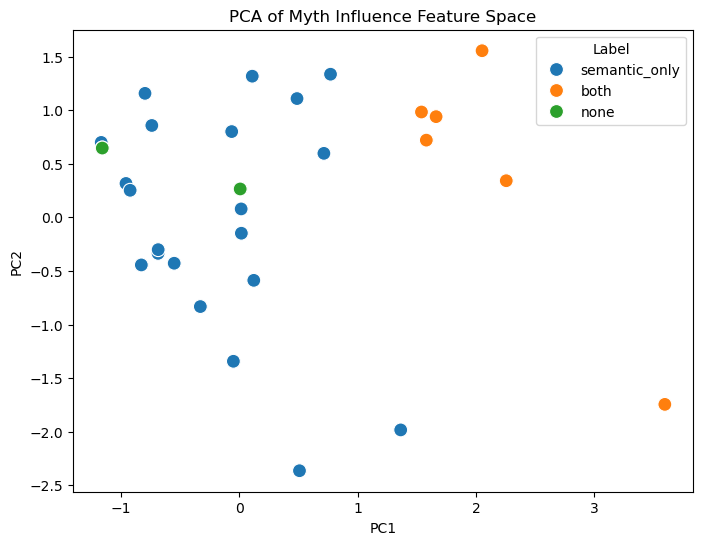

In [81]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# Get processed features from the pipeline
X_processed = model.named_steps['preprocess'].transform(X)

# Reduce to 2D for plotting
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_processed)

# Plot
df_plot = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
df_plot["Label"] = y.values

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_plot, x="PC1", y="PC2", hue="Label", s=100)
plt.title("PCA of Myth Influence Feature Space")
plt.show()

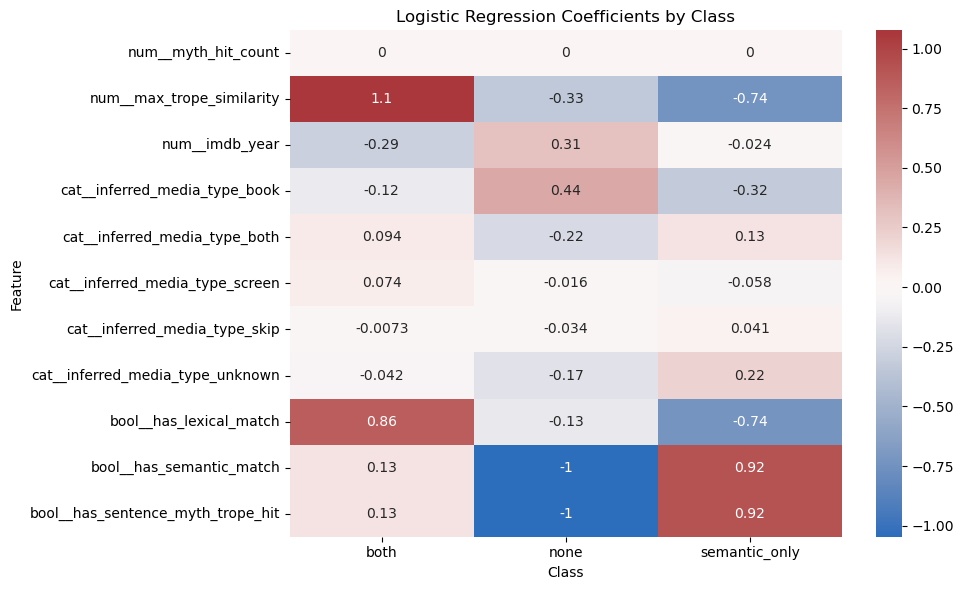

In [82]:
import seaborn as sns

# If not already created:
coef_df = pd.DataFrame(
    model.named_steps['clf'].coef_,
    columns=model.named_steps['preprocess'].get_feature_names_out(),
    index=model.named_steps['clf'].classes_
)

plt.figure(figsize=(10, 6))
sns.heatmap(coef_df.T, annot=True, center=0, cmap="vlag")
plt.title("Logistic Regression Coefficients by Class")
plt.xlabel("Class")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

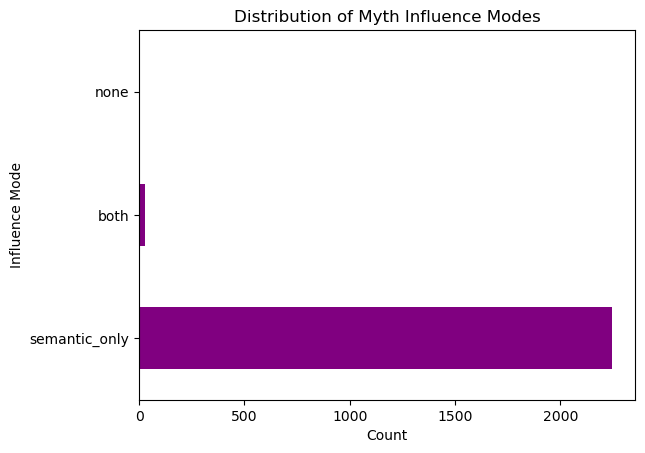

In [83]:
df['myth_influence_mode'].value_counts().plot(kind="barh", color="purple")
plt.title("Distribution of Myth Influence Modes")
plt.xlabel("Count")
plt.ylabel("Influence Mode")
plt.show()